# 01 · Design variants: four futures for Karlsplatz, Vienna

**Question:** which of four designs keeps Karlsplatz coolest on a hot summer afternoon?

This is the normal workflow: **your own model**. The four scenarios in
`../sample-data/vienna-demo/scenarios/` are plain GeoJSON files, as a planning
tool exports them (buildings with heights, trees, ground surfaces):

| Scenario | What changes |
|---|---|
| `01-baseline` | the real block today |
| `02-towers` | eight blocks become towers (up to 66 m) |
| `03-green` | more trees, all paving becomes green |
| `04-redevelopment` | the eastern third is cleared and becomes park |

We convert the GeoJSON into SDK inputs, run the **thermal comfort index (UTCI)**
for a hot week in July (13–16 h), and compare the four maps.

Data: © OpenStreetMap contributors (ODbL), trees: Stadt Wien – data.wien.gv.at (CC BY 4.0).

In [1]:
import json
import logging
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
from shapely.geometry import shape

from infrared_sdk import InfraredClient
from infrared_sdk.analyses.types import AnalysesName, UtciModelBaseRequest, UtciModelRequest
from infrared_sdk.models import Location, TimePeriod

import ir_plot as irp

os.environ["INFRARED_QUIET"] = "1"  # no progress lines
logging.getLogger("infrared_sdk").setLevel(logging.ERROR)  # no start-up notes
client = InfraredClient()  # reads INFRARED_API_KEY

DATA = Path("../sample-data/vienna-demo/scenarios")
SCENARIOS = ["01-baseline", "02-towers", "03-green", "04-redevelopment"]

## 1. Read the four scenarios

One folder for each scenario, with three layers.

In [2]:
def read(scenario: str, layer: str) -> dict:
    return json.loads((DATA / scenario / f"{layer}.geojson").read_text())

layers = {s: {k: read(s, k) for k in ("buildings", "trees", "surfaces")} for s in SCENARIOS}
pd.DataFrame({s: {k: len(v["features"]) for k, v in layers[s].items()} for s in SCENARIOS})

,01-baseline,02-towers,03-green,04-redevelopment
buildings,123,123,123,66
trees,362,362,500,362
surfaces,75,75,75,145


## 2. The area

The area is the bounding box of the baseline buildings. All four scenarios share it,
so the four result grids have the same cells.

In [3]:
w, s, e, n = gpd.GeoDataFrame.from_features(layers["01-baseline"]["buildings"]).total_bounds
polygon = {"type": "Polygon", "coordinates": [[[w, s], [e, s], [e, n], [w, n], [w, s]]]}
print(f"{(e - w) * 111_320 * np.cos(np.radians(s)):.0f} m x {(n - s) * 111_320:.0f} m")

518 m x 547 m


## 3. Convert GeoJSON to SDK inputs

**Buildings.** The SDK takes closed meshes in metres: x east, y north, z up, with the
origin at the south-west corner of the area. `irp.to_local` moves lon/lat into this frame.
We extrude each footprint to its `height_m`: floor, roof and walls.
Some real footprints have broken rings, so we repair them first (`make_valid`).
The SDK joins duplicate corners and fixes the triangle order for us.

In [4]:
def extrude(footprint, height: float) -> dict:
    """One closed mesh from a (multi)polygon footprint in lon/lat."""
    footprint = shapely.make_valid(footprint).buffer(0)  # real data has broken rings
    local = shapely.transform(  # lon/lat -> metres of the run frame
        footprint, lambda xy: np.column_stack(irp.to_local(xy[:, 0], xy[:, 1], polygon)))
    xyz: list[float] = []
    for tri in shapely.constrained_delaunay_triangles(local).geoms:
        a, b, c = tri.exterior.coords[:3]
        for z in (0.0, height):  # floor and roof
            xyz += [*a, z, *b, z, *c, z]
    for part in getattr(local, "geoms", [local]):
        for ring in [part.exterior, *part.interiors]:
            pts = list(ring.coords)
            for (x0, y0), (x1, y1) in zip(pts[:-1], pts[1:]):  # two triangles per wall
                xyz += [x0, y0, 0, x1, y1, 0, x1, y1, height,
                        x0, y0, 0, x1, y1, height, x0, y0, height]
    return {"coordinates": xyz, "indices": list(range(len(xyz) // 3))}

def to_buildings(fc: dict) -> dict:
    return {f"b{i}": extrude(shape(f["geometry"]), f["properties"]["height_m"])
            for i, f in enumerate(fc["features"])}

**Trees.** The SDK takes `{id: GeoJSON point feature}` in lon/lat with `genus`,
`height` and `crownDiameter` (metres). The genus sets the crown shape; we take it
from the first word of the species name.

**Ground.** The SDK takes one FeatureCollection for each material layer
(`asphalt`, `concrete`, `soil`, `vegetation`, `water`). We group the surfaces by `material`.

In [5]:
def to_trees(fc: dict) -> dict:
    trees = {}
    for i, f in enumerate(fc["features"]):
        p = f["properties"]
        trees[f"t{i}"] = {"type": "Feature", "geometry": f["geometry"], "properties": {
            "genus": p["species"].split()[0], "height": p["height"],
            "crownDiameter": p["crownDiameter"]}}
    return trees

def to_ground(fc: dict) -> dict:
    ground: dict = {}
    for f in fc["features"]:
        layer = ground.setdefault(f["properties"]["material"],
                                  {"type": "FeatureCollection", "features": []})
        layer["features"].append(f)
    return ground

inputs = {s: dict(buildings=to_buildings(l["buildings"]), vegetation=to_trees(l["trees"]),
                  ground_materials=to_ground(l["surfaces"])) for s, l in layers.items()}
print({s: len(v["buildings"]) for s, v in inputs.items()})

{'01-baseline': 123, '02-towers': 123, '03-green': 123, '04-redevelopment': 66}


## 4. Look at the model before you pay

A wrong frame or a wrong height gives a wrong result with no error. So draw the inputs on a map first.

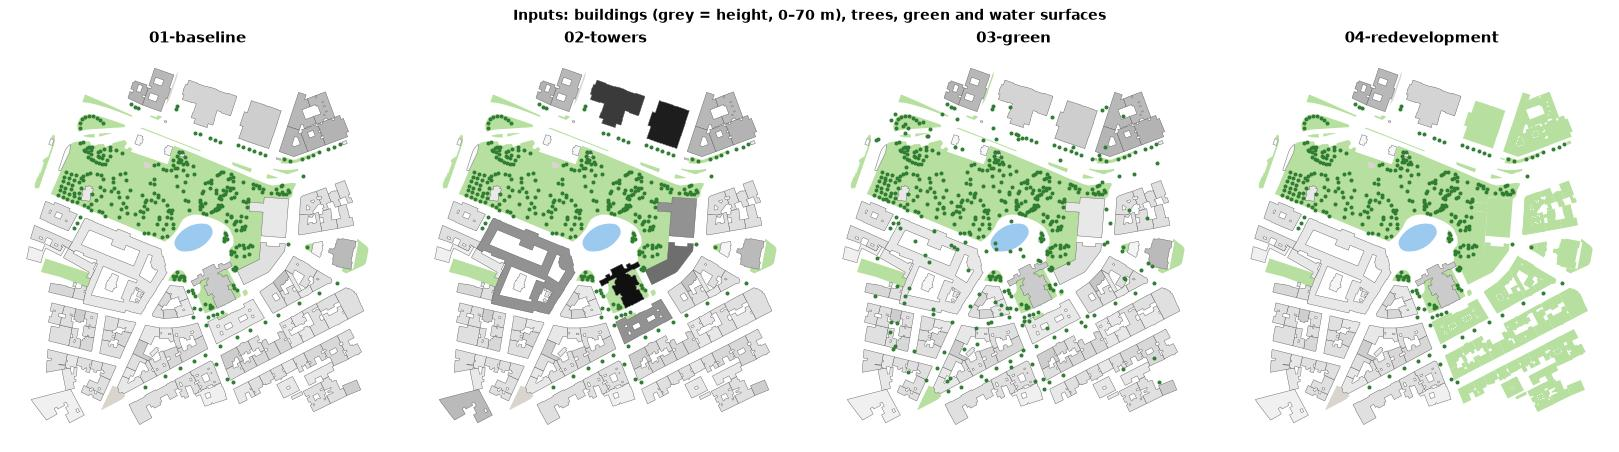

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6), layout="constrained")
for ax, name in zip(axes, SCENARIOS):
    gdfs = {k: gpd.GeoDataFrame.from_features(layers[name][k], crs=4326).to_crs(3857)
            for k in ("surfaces", "buildings", "trees")}
    gdfs["buildings"].geometry = gdfs["buildings"].make_valid()
    colours = gdfs["surfaces"]["material"].map(
        {"vegetation": "#b7dfa0", "water": "#9cc9ef", "concrete": "#d9d4cc"})
    gdfs["surfaces"].plot(ax=ax, color=colours, zorder=1)
    gdfs["buildings"].plot(ax=ax, column="height_m", cmap="Greys", vmin=0, vmax=70, zorder=2,
                           edgecolor="#555", linewidth=0.3)
    gdfs["trees"].plot(ax=ax, color="#2f7d32", markersize=4, zorder=3)
    ax.set_title(name)
    ax.set_axis_off()
fig.suptitle("Inputs: buildings (grey = height, 0–70 m), trees, green and water surfaces")
plt.show()

**What you see:** the four designs on the same site. Darker buildings are taller:
the eight towers of `02-towers` stand out. `03-green` has more trees and green ground,
and `04-redevelopment` has no buildings in the east.

## 5. Weather and time

The public weather catalog has a typical year for each station. We take the nearest station
and a hot week in July, 13 to 16 h. The SDK reads and checks the rows before it sends a job.

In [7]:
location = Location(latitude=(s + n) / 2, longitude=(w + e) / 2)
period = TimePeriod(start_month=7, start_day=15, start_hour=13,
                    end_month=7, end_day=21, end_hour=16)
station = client.weather.get_weather_file_from_location(lat=location.latitude, lon=location.longitude)[0]
hours = client.weather.filter_weather_data(identifier=station["uuid"], time_period=period)
air = [h.dryBulbTemperature for h in hours]
print(f"{station['fileName']}: {len(hours)} hours, air {min(air):.0f} to {max(air):.0f} °C")

request = UtciModelRequest.from_weatherfile_payload(
    payload=UtciModelBaseRequest(analysis_type=AnalysesName.thermal_comfort_index),
    location=location, time_period=period, weather_data=hours)

AUT_WI_Wien-Innere.Stadt.110340_TMYx.2009-2023: 28 hours, air 22 to 31 °C


## 6. Preview and run

The preview is free. One scenario is one area run.

In [8]:
preview = client.preview_area(polygon, payload=request)
print(f"each scenario: {preview.would_bill_jobs} jobs, {preview.estimated_cost_tokens} tokens; "
      f"all four: {4 * preview.estimated_cost_tokens} tokens")

each scenario: 4 jobs, 40 tokens; all four: 160 tokens


In [9]:
utci = {name: irp.cached(f"vienna-utci-{name}",
                         lambda: client.run_area_and_wait(request, polygon, **inputs[name]))
        for name in SCENARIOS}

## 7. Four maps, one scale

One shared colour scale, so the same colour means the same UTCI in each map.

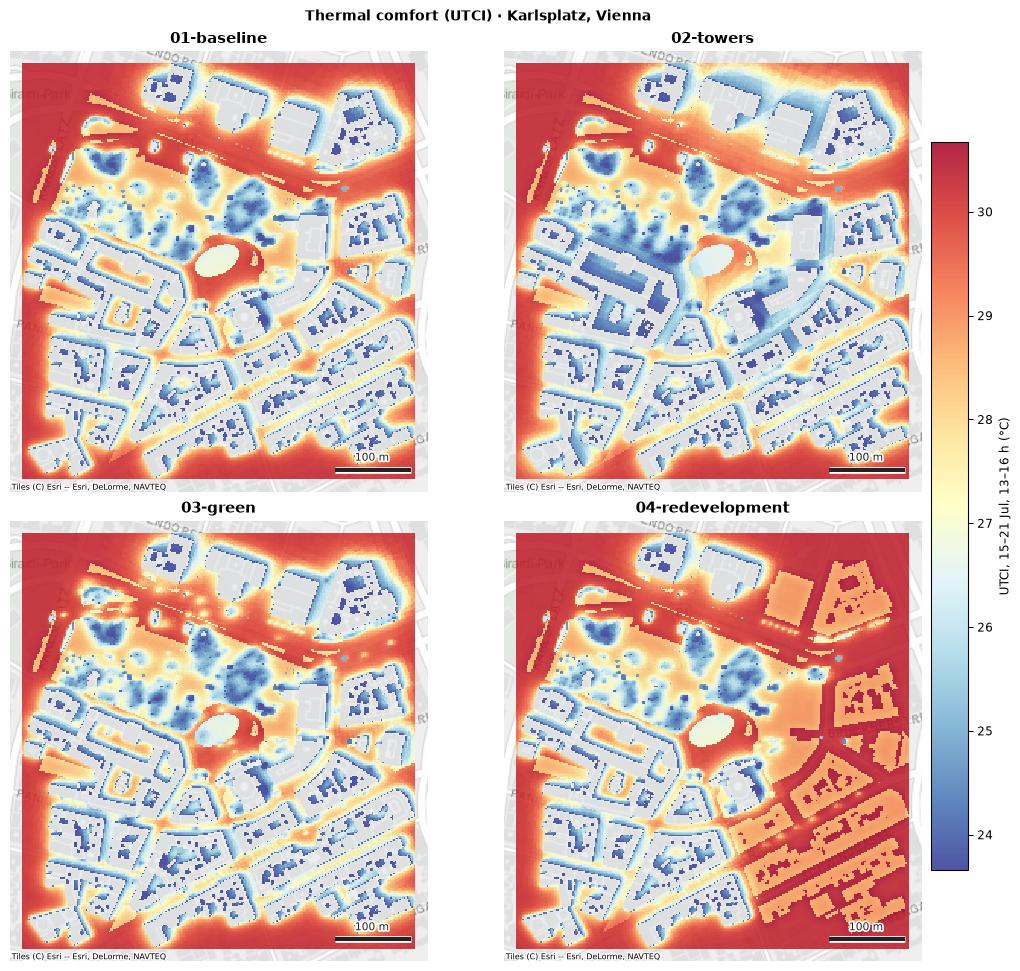

In [10]:
grids = [utci[s] for s in SCENARIOS]
lo = min(np.nanpercentile(g.values, 1) for g in grids)
hi = max(np.nanpercentile(g.values, 99) for g in grids)
irp.map_grids(grids, SCENARIOS, ncols=2, vmin=lo, vmax=hi, panel=5,
              label="UTCI, 15–21 Jul, 13–16 h (°C)",
              suptitle="Thermal comfort (UTCI) · Karlsplatz, Vienna")
plt.show()

**What you see:** blue is shade: under the trees of Resselpark and in the narrow
streets. Red is open sun: the wide roads in the north and the plazas. The towers of
`02-towers` throw long shade to the north-east. In `04-redevelopment` the cleared
blocks become open park in full afternoon sun (orange).

## 8. Difference to the baseline

Blue is cooler than today, red is warmer. Cells inside a building of either design have no value.

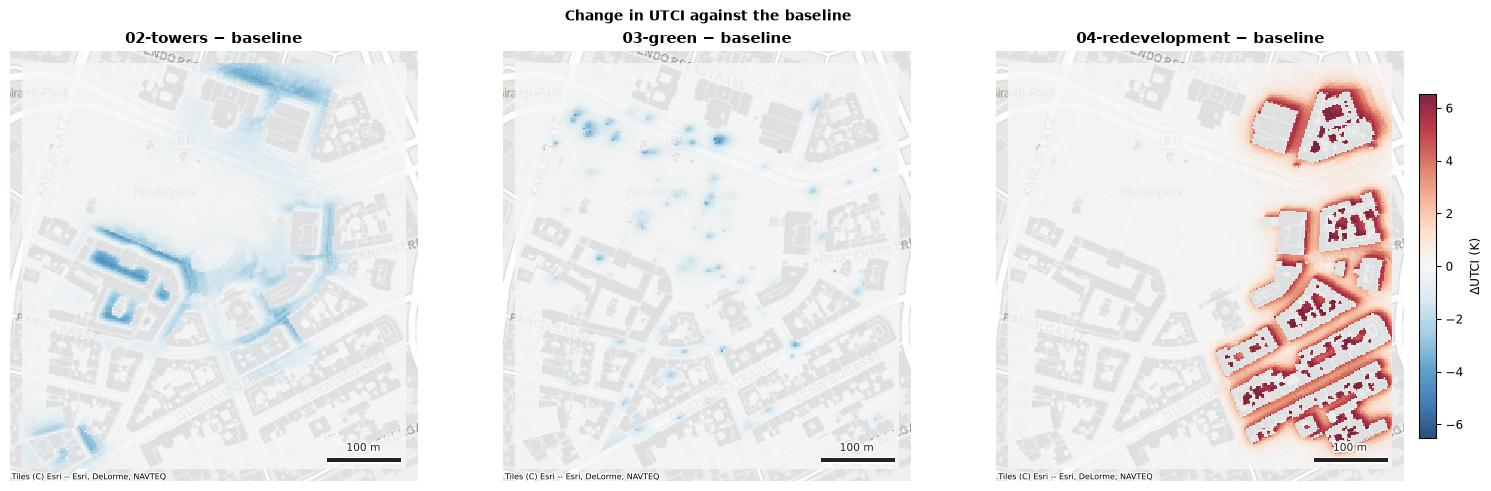

In [11]:
deltas = [utci[s] - utci["01-baseline"] for s in SCENARIOS[1:]]
limit = max(irp.symmetric_limit(d) for d in deltas)
irp.map_grids(deltas, [f"{s} − baseline" for s in SCENARIOS[1:]], cmap="RdBu_r",
              vmin=-limit, vmax=limit, label="ΔUTCI (K)", panel=5,
              suptitle="Change in UTCI against the baseline")
plt.show()

**What you see:** the towers cool their afternoon shade by several kelvin.
The new trees of `03-green` make small cool spots, one under each crown. The
redevelopment is warmer by up to about 6 K: the buildings and their shade are gone,
and the new park does not replace the shade at this hour.

## 9. Area means

For a fair comparison we use only the cells that are open ground in **all four** designs.

In [12]:
common = np.logical_and.reduce([np.isfinite(g.values) for g in grids])
base = utci["01-baseline"].values[common]
table = pd.DataFrame({
    "mean UTCI (°C)": [g.values[common].mean() for g in grids],
    "Δ mean (K)": [g.values[common].mean() - base.mean() for g in grids],
    "heat stress, UTCI > 26 °C (% of area)": [100 * (g.values[common] > 26).mean() for g in grids],
}, index=SCENARIOS).astype(float).round(2)
print(f"{common.sum():,} common cells of 1 m²")
table

204,643 common cells of 1 m²


,mean UTCI (°C),Δ mean (K),"heat stress, UTCI > 26 °C (% of area)"
01-baseline,27.77,0.00,77.74
02-towers,27.36,-0.41,69.76
03-green,27.63,-0.14,75.77
04-redevelopment,28.58,0.81,85.25


**What you see:** on the shared open ground, the towers give the lowest mean,
the new trees a small gain, and the cleared east a loss. A mean hides local effects:
read the table together with the maps.

## Next

- Your own design tool: export the same three GeoJSON layers and reuse `to_buildings`,
  `to_trees` and `to_ground`.
- `02_summer_heat`: UTCI and heat-stress hours with an EPW file.
- Guide, inputs: <https://infrared.city/docs/sdk/1.0/#your-inputs>